In [2]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

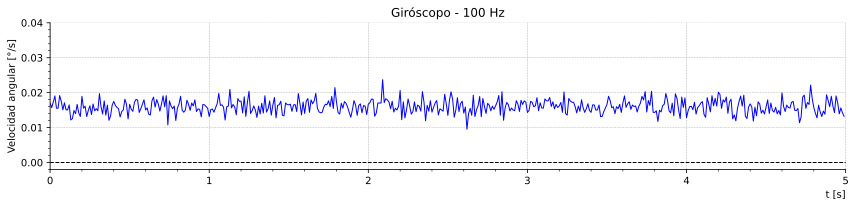

In [7]:
#| label: gyro-simulated
#| fig-cap: ""
#| fig-align: center

# Parámetros
fs = 100            # Frecuencia de muestreo [Hz]
duration = 5        # Duración [s]
sigma = 0.002       # Desviación estándar del ruido [°/s]
mu = 0.016           # Bias [°]

# Vector de tiempo
t = np.arange(0, duration, 1 / fs)

# Semilla para obtener siempre el mismo resultado
np.random.seed(42)

# Giróscopo estático:
# velocidad angular ideal = 0
# medición = valor ideal + bias + ruido
gyro = mu + np.random.normal(loc=0.0, scale=sigma, size=len(t))

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(12, 3))

# Dibujar la señal
ax.plot(t, gyro, linewidth=1, color='blue')

# Recta de valor ideal
ax.axhline(0, color='k', linestyle='--', linewidth=1, label='Valor ideal')

# # Bias
# ax.axhline(
#     mu,
#     color='red',
#     linestyle=':',
#     linewidth=1,
#     label='Bias'
# )


# Ocultar ejes de arriba y derecha
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Etiquetas en español
ax.set_xlabel('t [s]', loc='right')
ax.set_ylabel('Velocidad angular [°/s]')

# Límites
ax.set_xlim(0, duration)
ax.set_ylim(-0.002, 0.04)

# Cuadrículas
ax.minorticks_on()
ax.grid(True, which='major', linestyle='--', linewidth=0.5)

# Título y leyenda
plt.title('Giróscopo - 100 Hz')
# ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

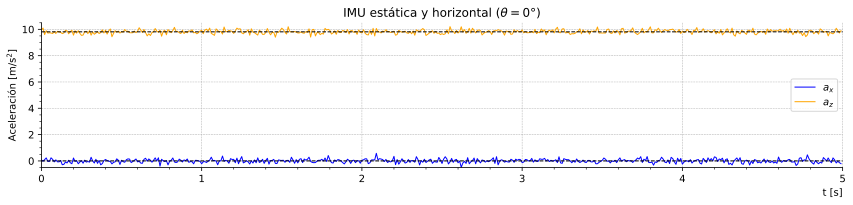

In [36]:
#| label: imu-horizontal
#| fig-cap: ""
#| fig-align: center

# Parámetros
fs = 100            # Frecuencia de muestreo [Hz]
duration = 5        # Duración [s]
sigma = 0.15        # Desviación estándar del ruido [m/s²]
g = 9.81            # Gravedad [m/s²]

# Vector de tiempo
t = np.arange(0, duration, 1 / fs)

# Semilla para obtener siempre el mismo resultado
np.random.seed(42)

# IMU estática y horizontal
# X: no hay componente de gravedad
ax_data = np.random.normal(loc=0.0, scale=sigma, size=len(t))

# Z: la gravedad está completamente proyectada sobre Z
az_data = g + np.random.normal(loc=0.0, scale=sigma, size=len(t))

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(12, 3))

# Dibujar las señales
ax.plot(t, ax_data, color='blue',linewidth=1, label=r'$a_x$')
ax.plot(t, az_data, color='orange',linewidth=1, label=r'$a_z$')

# Valores ideales
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.axhline(g, color='k', linestyle='--', linewidth=1)

# Ocultar ejes de arriba y derecha
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Etiquetas
ax.set_xlabel('t [s]', loc='right')
ax.set_ylabel(r'Aceleración [m/s$^2$]')

# Límites
ax.set_xlim(0, duration)
ax.set_ylim(-0.5, 10.5)

# Cuadrícula
ax.minorticks_on()
ax.grid(True, which='major', linestyle='--', linewidth=0.5)

# Título y leyenda
plt.title(r'IMU estática y horizontal ($\theta = 0°$)')
ax.legend(loc='center right')

plt.tight_layout()
plt.show()

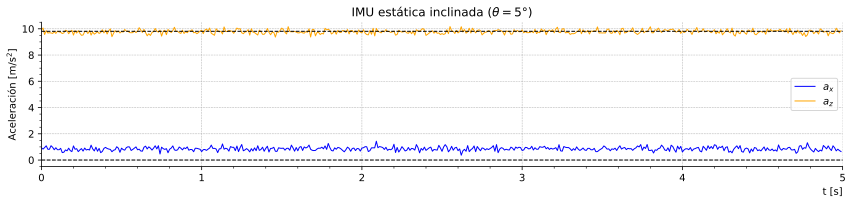

In [37]:
#| label: imu-tilted
#| fig-cap: ""
#| fig-align: center

# Parámetros
fs = 100            # Frecuencia de muestreo [Hz]
duration = 5        # Duración [s]
sigma = 0.15        # Desviación estándar del ruido [m/s²]
g = 9.81            # Gravedad [m/s²]
theta = 5           # Inclinación en pitch [°]

# Vector de tiempo
t = np.arange(0, duration, 1 / fs)

# Semilla para obtener siempre el mismo resultado
np.random.seed(42)

# IMU estática pero inclinada
# X: hay componente de gravedad (sin(theta))
ax_data = np.sin(np.deg2rad(theta)) * g + np.random.normal(loc=0.0, scale=sigma, size=len(t))

# Z: la gravedad no está 100% proyectada sobre Z (cos(theta))
az_data = np.cos(np.deg2rad(theta)) * g + np.random.normal(loc=0.0, scale=sigma, size=len(t))

# Crear la figura y los ejes
fig, ax = plt.subplots(figsize=(12, 3))

# Dibujar las señales
ax.plot(t, ax_data, color='blue',linewidth=1, label=r'$a_x$')
ax.plot(t, az_data, color='orange',linewidth=1, label=r'$a_z$')

# Valores ideales
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.axhline(g, color='k', linestyle='--', linewidth=1)

# Ocultar ejes de arriba y derecha
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Etiquetas
ax.set_xlabel('t [s]', loc='right')
ax.set_ylabel(r'Aceleración [m/s$^2$]')

# Límites
ax.set_xlim(0, duration)
ax.set_ylim(-0.5, 10.5)

# Cuadrícula
ax.minorticks_on()
ax.grid(True, which='major', linestyle='--', linewidth=0.5)

# Título y leyenda
plt.title(rf'IMU estática inclinada ($\theta = {theta}°$)')
ax.legend(loc='center right')

plt.tight_layout()
plt.show()